# ReGRID model analysis

### Scenario comparisons

Developed: 30 January, 2026

Note:
- This notebook depends on results generated by the following notebooks:
  - model.py
  - analysis_system.ipynb

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import os

In [2]:
# Case setting
TERM = '1y' # Analysis term: 1y=Yearly
STEP = 6 # Timestep(h)
VER = 'v8' # Model version
YEAR = 2050 # Target year
BOUNDARY = 'japan' # Spatial boundary
NETWORK = '1741' # TSN:Transmission, '1741':Municipality
PATHWAY = 'C1' # Socioeconomic and emission pathway: C1:1.5C, C7:below 4C
POTENTIAL_AVAILABILITY = 100 # Uniform availability of renewable energy(%)
POTENTIAL_CASE = 'high' # Renewable energy potential assumptions ('base':HPA, 'low':PA+OECM, 'mid':Enhanced, 'high':FullProtect)
COST_CASE = 'moderate' # Cost assumption

TECH_CASE = 'ccs-biomass'
if TECH_CASE == 'ccs-biomass':
    CCS_AVAILAVILITY = 2 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 2 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 0.1 # Availability of technical potential
else:
    CCS_AVAILAVILITY = 1 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 1 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 1 # Availability of technical potential

In [3]:
# Initialize a model
def get_model_name(ver=VER, year=YEAR, pathway=PATHWAY, term=TERM, step=STEP, boundary=BOUNDARY, network=NETWORK, nuclear=NUCLEAR_AVAILABILITY, potential=POTENTIAL_AVAILABILITY, potential_case=POTENTIAL_CASE, cost_case=COST_CASE, tech_case=TECH_CASE):
    return f"ReGRID2_{ver}_{year}_{pathway}_{term}_{step}_{boundary}_{network}_n{nuclear}_p{potential}_{potential_case}_{cost_case}_{tech_case}"

model_name = get_model_name()
print(model_name)

ReGRID2_v8_2050_C1_1y_6_japan_1741_n2_p100_high_moderate_ccs-biomass


In [4]:
output_path = 'output/analysis'
if not os.path.exists(output_path):
    os.makedirs(output_path, exist_ok=True)

In [5]:
# Data for analysis

VRE = ['solar','onwin','of-fx','of-fl']
CASES = ['base','low','mid','high']
CASE_NAME = {'low':'PA+OECM', 'mid':'Enhanced', 'high':'FullProtect', 'sea':'MarineProtect', 'land':'LandProtect', 'base':'HPA'}

# Technology list
RESOURCE = ['hydro','geoth','river','onwin','of-fx','of-fl','solar']
WASTE = ['waste','msw-c']
WOODY = ['woody','beccs']
FOSSIL = ['coalp','coalc','gas-p','gas-c','oil-p']
STORAGE = ['stpmp','stbat']
H2TECH = ['st-h2','el-h2','h2-el']
AUX = ['stpcs','h2cmp']
DACCS = ['daccs']
if NUCLEAR_AVAILABILITY != 0:
    THERMAL = FOSSIL + ['nuclr']
else:
    THERMAL = FOSSIL
    
# Technology dataset (Cost, Efficiency, etc.)
P = pd.read_csv(f'input/technology/technology_C1.csv', index_col=0)
P = P[(P['year'] == 2050) & (P['scenario'] == 'moderate')]

USD = 107 # JPY/USD

In [6]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['font.size'] = 6
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5

MAX_WIDTH = 180 / 25.4 # inch in 180mm

HPA            121.609417
PA+OECM        123.980375
Enhanced       127.015911
FullProtect    144.366886
dtype: float64


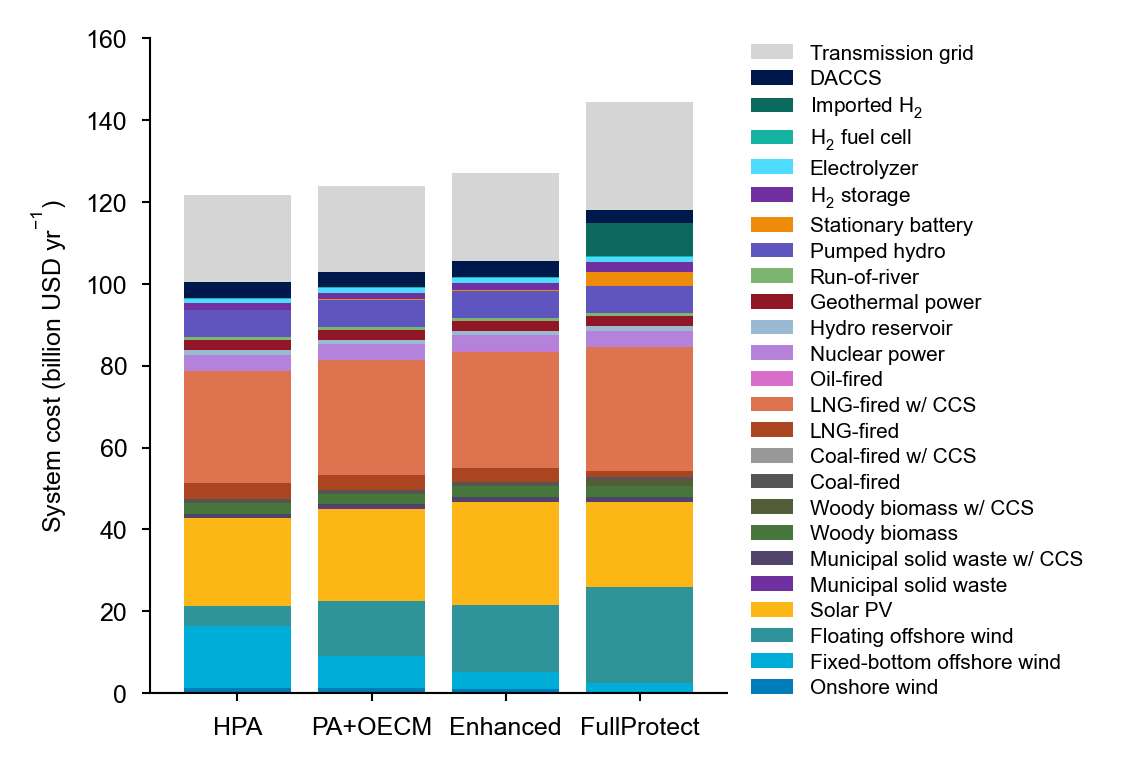

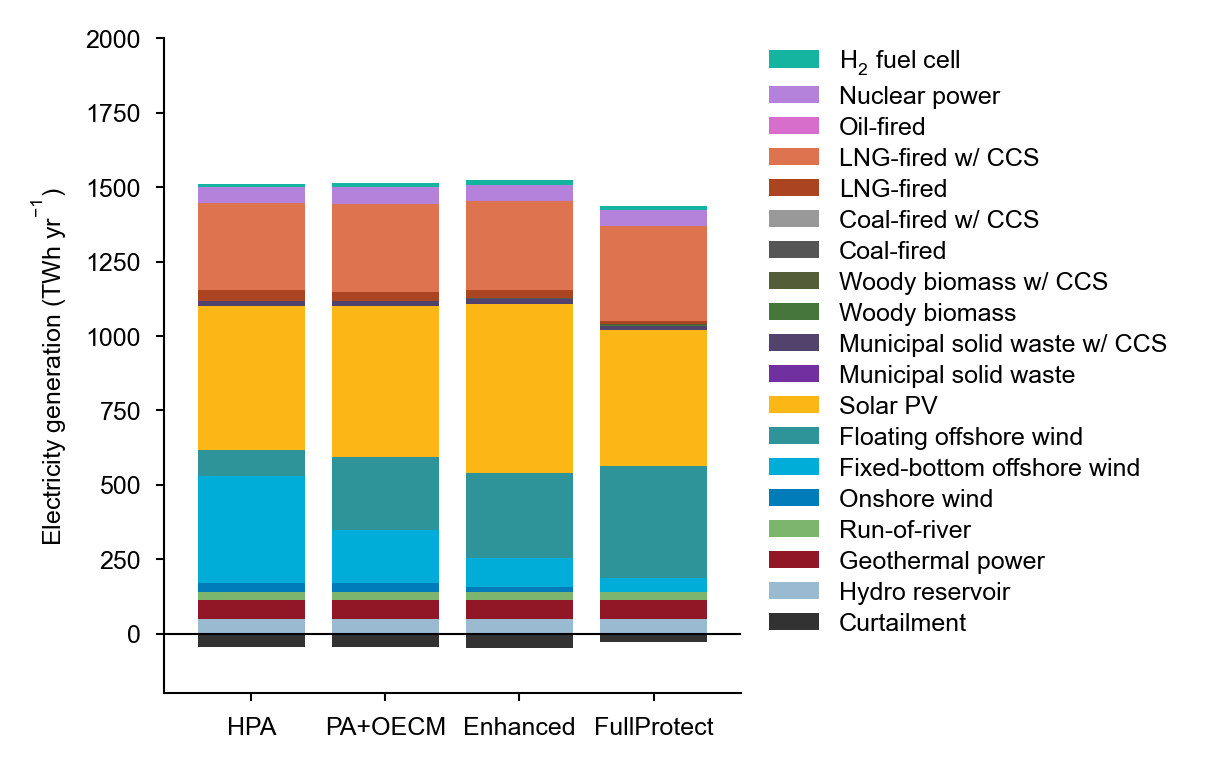

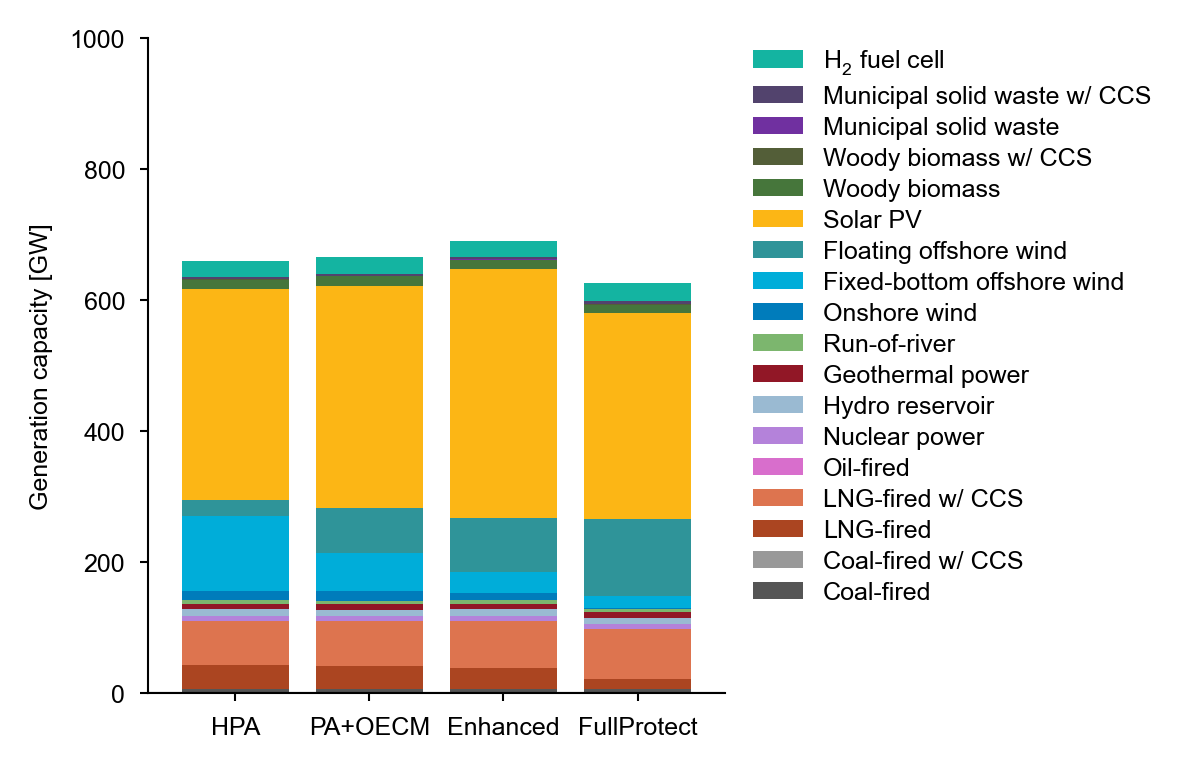

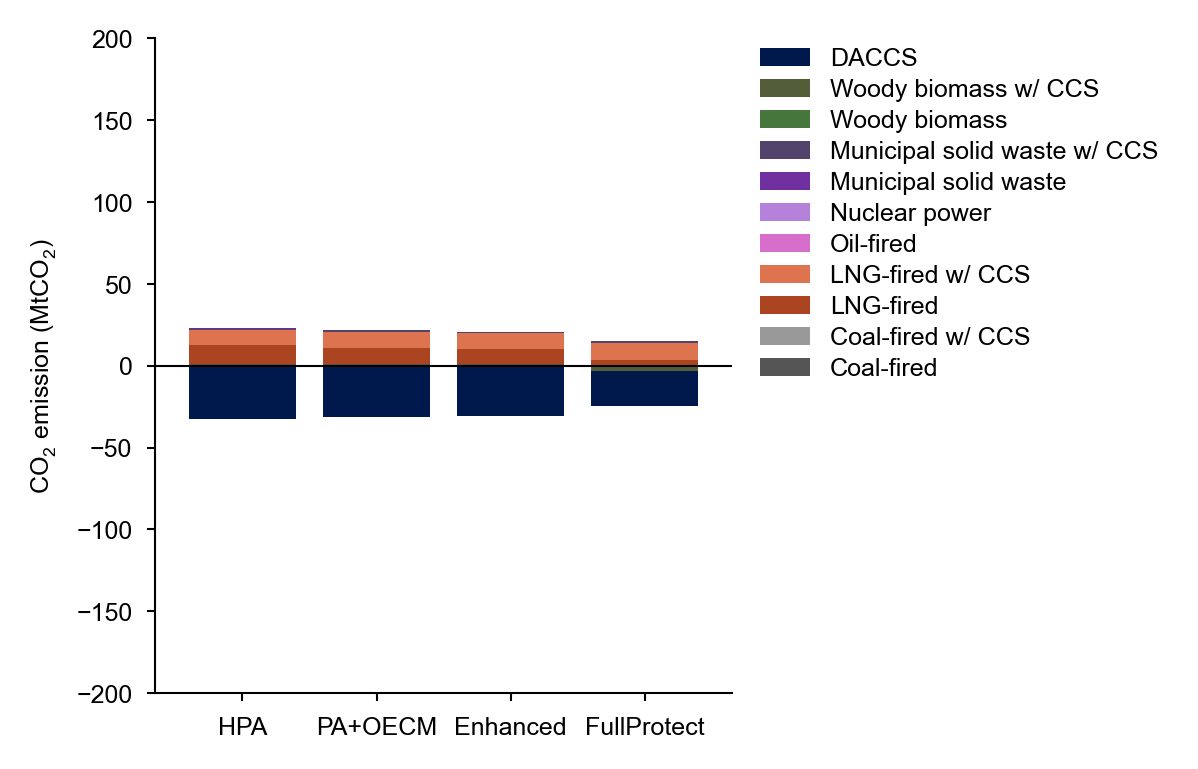

In [7]:
# Case comparison

def comparison_plot(data, label, title, ymin, ymax, file_name, legend_size):

    fig, ax = plt.subplots(1, 1, gridspec_kw={'wspace':0.04}, figsize=[MAX_WIDTH*0.35,MAX_WIDTH*0.4], dpi=300)

    # Stack plot
    data.plot(kind='bar', stacked=True, ax=ax, color=[P['color'][abr] for abr in data.columns], legend=None, linewidth=0, width=0.8)
    ax.tick_params(bottom=False, axis='y')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel(label)
    ax.set_xlabel("", fontsize=0)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    handles, labels = ax.get_legend_handles_labels() 
    plt.legend(handles[::-1], [P['name'][abr] for abr in data.columns][::-1], bbox_to_anchor=(1.01, 1.02), labelspacing=0.32, loc='upper left', frameon = False, fontsize=legend_size, ncol=1)
    plt.subplots_adjust(wspace=0.05)

    plt.savefig(f'{output_path}/{file_name}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{output_path}/{file_name}.pdf', bbox_inches='tight', dpi=300)
    plt.show()


pathway = 'C1'
nuclear_set = {'ccs-biomass':2, 'opt':1}
year = 2050

case_results = {}
for tech_case in ['ccs-biomass']:
    for param in ['cost','generation','capacity','emission']:
        case_results[param] = pd.DataFrame()
        for case in CASES:
            model_name = get_model_name(year=year, pathway=pathway, potential_case=case, tech_case=tech_case, nuclear=nuclear_set[tech_case])
            case_results[param][CASE_NAME[case]] = pd.read_csv(f'output/{model_name}/{param}_{model_name}.csv', index_col=0)
            
    print(case_results['cost'].sum() / 107 * 1000)

    P.at['crt','color'] = "#323232"
    plot_id = f"_{tech_case}_{str(year)}_{pathway}"
    comparison_plot(case_results['cost'].T / USD * 1000, 'System cost (billion USD yr$^{-1}$)', 'cost', 0, 160, 'comparison_cost'+plot_id, 5)
    comparison_plot(case_results['generation'].T / 1000000, 'Electricity generation (TWh yr$^{-1}$)', 'generation', -200, 2000, 'comparison_generation'+plot_id, 6)
    comparison_plot(case_results['capacity'].T[THERMAL+RESOURCE+WOODY+WASTE+['h2-el']] / 1000, 'Generation capacity [GW]', 'capacity', 0, 1000, 'comparison_capacity'+plot_id, 6)
    comparison_plot(case_results['emission'].T, r'CO$_{2}$ emission (MtCO$_{2}$)', 'emission', -200, 200, 'comparison_emission'+plot_id, 6)

System cost increase (%)
         base        low        mid       high
C1  19.800587  22.136279  25.126664   42.21956
C3  15.815664  17.784218  19.970573   26.48212
C7   7.716294   9.081284  10.596476  12.889569
System cost (billion USD/year)
         base        low        mid        high
C1  89.730259  91.479685  93.719474  106.521999
C3  86.745564  88.220005  89.857578   94.734706
C7  80.679162  81.701535  82.836409   84.553928


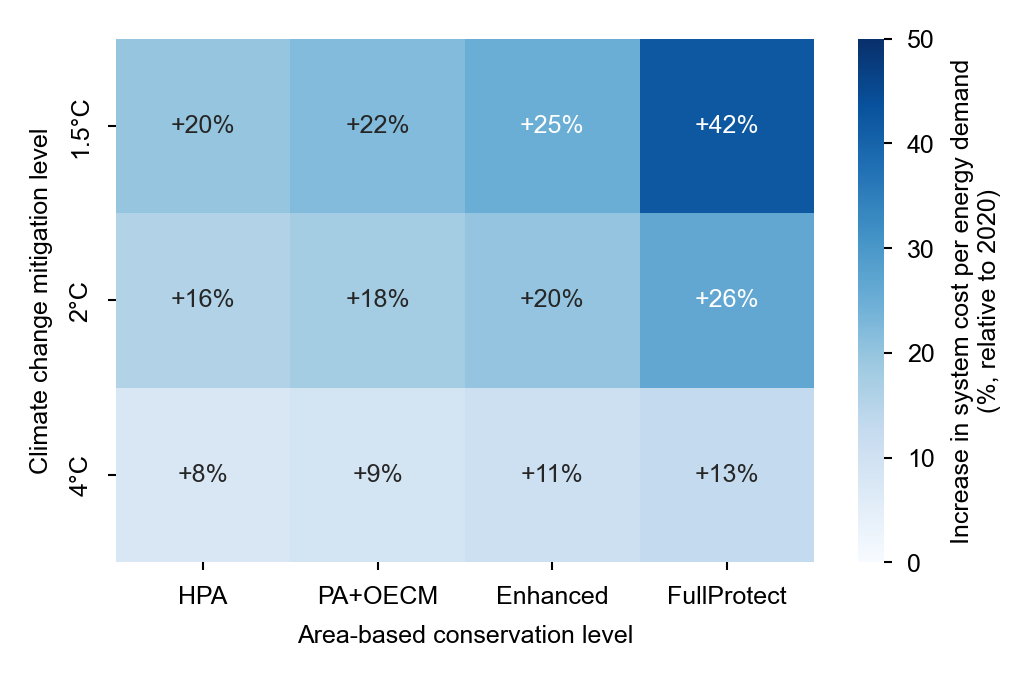

In [8]:
import seaborn as sns

PATHWAYS = ['C1','C3','C7']
tech_case = 'ccs-biomass'
year = 2050

cost_matrix = pd.DataFrame(index=PATHWAYS, columns=CASES)
total_cost_list = {}
for pathway in PATHWAYS:
    for case in CASES:
        model_name = get_model_name(year=year, pathway=pathway, potential_case=case, tech_case=tech_case, nuclear=nuclear_set[tech_case])
        cost_matrix[case][pathway] = pd.read_csv(f'output/{model_name}/cost_total_{model_name}.csv', index_col=0)['0']['unit_cost']


# cost_matrix = (cost_matrix / total_cost_list['base'] - 1) * 100
# cost_matrix = cost_matrix.sort_index(ascending=False)
# cost_matrix


def heatmap_plot(data, label, cmap, vmin, vmax, file_name):

    fig, ax = plt.subplots(1, 1, figsize=[MAX_WIDTH*0.53, MAX_WIDTH*0.32], dpi=300)

    annot = pd.DataFrame("", index=data.index, columns=data.columns)
    rows, cols = data.shape
    annot.iloc[0, 0] = f"+{data.iloc[0,0]:.0f}%"
    annot.iloc[0, -1] = f"+{data.iloc[0,-1]:.0f}%"
    annot.iloc[0, -2] = f"+{data.iloc[0,-2]:.0f}%"
    annot.iloc[0, -3] = f"+{data.iloc[0,-3]:.0f}%"
    annot.iloc[1, 0] = f"+{data.iloc[1,0]:.0f}%"
    annot.iloc[1, -1] = f"+{data.iloc[1,-1]:.0f}%"
    annot.iloc[1, -2] = f"+{data.iloc[1,-2]:.0f}%"
    annot.iloc[1, -3] = f"+{data.iloc[1,-3]:.0f}%"
    annot.iloc[2, 0] = f"+{data.iloc[2,0]:.0f}%"
    annot.iloc[2, -1] = f"+{data.iloc[2,-1]:.0f}%"
    annot.iloc[2, -2] = f"+{data.iloc[2,-2]:.0f}%"
    annot.iloc[2, -3] = f"+{data.iloc[2,-3]:.0f}%"

    sns.heatmap(data.to_numpy(dtype=float), ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, annot=annot, fmt="", annot_kws={"size": 6}, cbar_kws={'shrink': 1.0, 'label': label})

    cbar = ax.collections[0].colorbar
    
    ax.set_xticklabels(['HPA','PA+OECM','Enhanced','FullProtect'])
    ax.set_yticklabels(['1.5°C','2°C','4°C'])
    ax.set_xlabel("Area-based conservation level", fontsize=6)
    ax.set_ylabel("Climate change mitigation level", fontsize=6)
    
    plt.savefig(f'{output_path}/{file_name}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{output_path}/{file_name}.pdf', bbox_inches='tight')
    plt.show()


model_name = get_model_name(year=2020, pathway='C7', potential_case='base', tech_case='ccs-biomass', nuclear=2)
cost_2020 = pd.read_csv(f'output/{model_name}/cost_total_{model_name}.csv', index_col=0)['0']['unit_cost']

cost_matrix_gap = ((cost_matrix / cost_2020) - 1) * 100
cost_matrix = cost_matrix / USD * 1000

print("System cost increase (%)")
print(cost_matrix_gap)

print("System cost (billion USD/year)")
print(cost_matrix)


heatmap_plot(cost_matrix_gap, 'Increase in system cost per energy demand\n(%, relative to 2020)', cm.Blues, 0, 50, f'cost_matrix_pathways_gap')

                  base        low        mid       high
ccs-biomass  19.800587  22.136279  25.126664   42.21956
opt            20.9025  22.683741  24.653229  28.260854
                  base        low        mid        high
ccs-biomass  89.730259  91.479685  93.719474  106.521999
opt          90.555589  91.889733  93.364873   96.066972


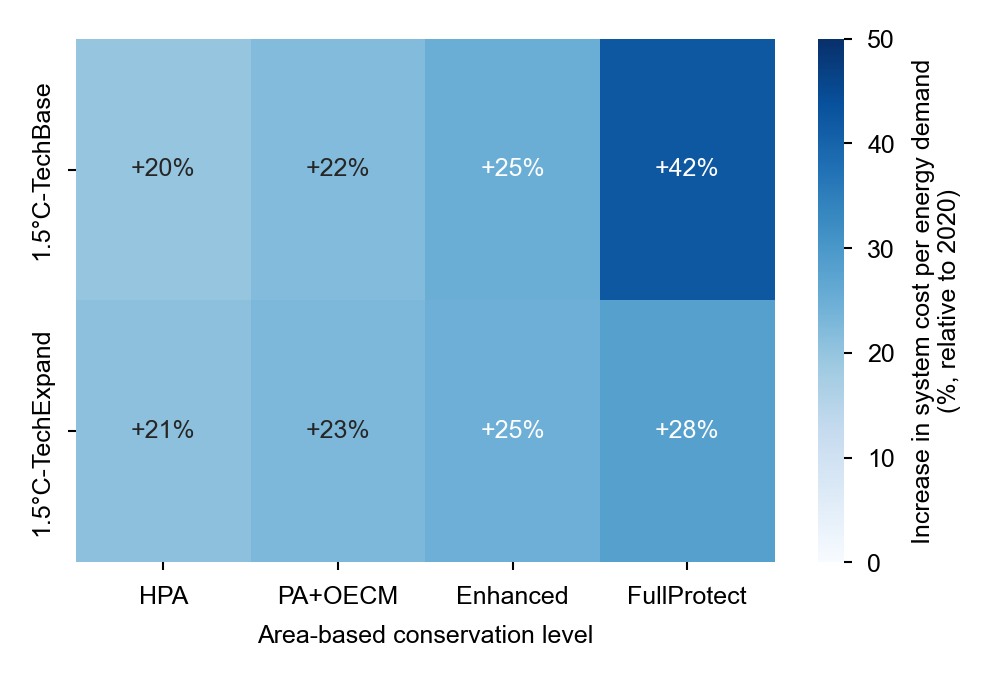

In [10]:
TECH = ['ccs-biomass','opt']
pathway = 'C1'
year = 2050

cost_matrix = pd.DataFrame(index=TECH, columns=CASES)
total_cost_list = {}
for tech_case in TECH:
    for case in CASES:
        model_name = get_model_name(year=year, pathway=pathway, potential_case=case, tech_case=tech_case, nuclear=nuclear_set[tech_case])
        cost_matrix[case][tech_case] = pd.read_csv(f'output/{model_name}/cost_total_{model_name}.csv', index_col=0)['0']['unit_cost']


def heatmap_plot(data, label, cmap, vmin, vmax, file_name):
    
    font_size = 6
    plt.rcParams['font.size'] = font_size
    plt.rcParams['xtick.labelsize'] = font_size
    plt.rcParams['ytick.labelsize'] = font_size

    fig, ax = plt.subplots(1, 1, figsize=[MAX_WIDTH*0.53, MAX_WIDTH*0.32], dpi=300)

    annot = pd.DataFrame("", index=data.index, columns=data.columns)
    rows, cols = data.shape
    annot.iloc[0, 0] = f"+{data.iloc[0,0]:.0f}%"
    annot.iloc[0, -1] = f"+{data.iloc[0,-1]:.0f}%"
    annot.iloc[0, -2] = f"+{data.iloc[0,-2]:.0f}%"
    annot.iloc[0, -3] = f"+{data.iloc[0,-3]:.0f}%"
    annot.iloc[1, 0] = f"+{data.iloc[1,0]:.0f}%"
    annot.iloc[1, -1] = f"+{data.iloc[1,-1]:.0f}%"
    annot.iloc[1, -2] = f"+{data.iloc[1,-2]:.0f}%"
    annot.iloc[1, -3] = f"+{data.iloc[1,-3]:.0f}%"

    sns.heatmap(data.to_numpy(dtype=float), ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, annot=annot, fmt="", annot_kws={"size": 6}, cbar_kws={'shrink': 1.0, 'label': label})

    cbar = ax.collections[0].colorbar
    
    ax.set_xticklabels(['HPA','PA+OECM','Enhanced','FullProtect'])
    ax.set_yticklabels(['1.5°C-TechBase','1.5°C-TechExpand'])
    ax.set_xlabel("Area-based conservation level", fontsize=font_size)
    
    plt.savefig(f'{output_path}/{file_name}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{output_path}/{file_name}.pdf', bbox_inches='tight')
    plt.show()
    
    plt.rcParams['font.size'] = 7
    plt.rcParams['xtick.labelsize'] = 7
    plt.rcParams['ytick.labelsize'] = 7


model_name = get_model_name(year=2020, pathway='C7', potential_case='base', tech_case='ccs-biomass', nuclear=2)
cost_2020 = pd.read_csv(f'output/{model_name}/cost_total_{model_name}.csv', index_col=0)['0']['unit_cost']

cost_matrix_gap = ((cost_matrix / cost_2020) - 1) * 100
cost_matrix = cost_matrix / USD * 1000
print(cost_matrix_gap)
print(cost_matrix)


heatmap_plot(cost_matrix_gap, 'Increase in system cost per energy demand\n(%, relative to 2020)', cm.Blues, 0, 50, f'cost_matrix_technology_gap')